# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">
<b>Comentário geral v1: </b> <a class="tocSkip"></a>
    
Parabéns pela conclusão do projeto, Iago! 

O seu código está bem organizado e segue uma boa estrutura para projetos de ciência de dados. A separação em tarefas ajuda bastante na leitura e no entendimento do processo. Deixo abaixo os pontos positivos e também e sugestões de melhoria:

**Pontos positivos:**

- Pipeline bem estruturado: o fluxo de carregamento, preparação, treino e avaliação do modelo está claro e bem definido.

- Pré-processamento correto: você removeu colunas irrelevantes, aplicou StandardScaler, etc.

- Correto tratamento de dados desbalanceados: Utilizou técnicas como oversampling para prevenir as limitações de desbalanceamento.


No mais, um ótimo projeto! Parabéns e continue evoluindo ainda mais! <3 

In [1]:
# Importação das bibliotecas

# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem e métricas
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils import resample  # usado para oversampling manual

# Modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configurações visuais
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Leitura e inspeção inicial dos dados

PATH = '/datasets/Churn.csv'

# Leitura
df = pd.read_csv(PATH)

# Estrutura geral
print("Shape:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos de dados:")
print(df.dtypes)

print("\nPrimeiras linhas:")
display(df.head())

print("\nValores ausentes por coluna:")
print(df.isna().sum())

# Distribuição da variável-alvo
if 'Exited' in df.columns:
    target_counts = df['Exited'].value_counts()
    print("\nContagem da variável-alvo (Exited):")
    print(target_counts)
    print("\nProporção da variável-alvo (Exited):")
    print((target_counts / len(df)).round(4))
else:
    print("\n[AVISO] Coluna 'Exited' não encontrada. Verifique o CSV.")

Shape: (10000, 14)

Colunas:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Tipos de dados:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure             float64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Primeiras linhas:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0



Valores ausentes por coluna:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

Contagem da variável-alvo (Exited):
0    7963
1    2037
Name: Exited, dtype: int64

Proporção da variável-alvo (Exited):
0    0.7963
1    0.2037
Name: Exited, dtype: float64


### Leitura e inspeção inicial dos dados)

#### Estrutura geral

O dataset contém **10.000 registros** e **14 colunas**, representando clientes do **Beta Bank**.
Há variáveis de identificação, demográficas e financeiras, além da variável-alvo `Exited`.

#### Valores ausentes

* A coluna **`Tenure`** apresenta **909 valores ausentes**, correspondendo a cerca de **9% do total**.

  * Essa variável indica o tempo (em anos) que o cliente mantém o depósito fixo.
  * Como é uma variável **numérica discreta e interpretável**, podemos futuramente:

    * preencher os ausentes com a **mediana** (estratégia simples e robusta contra outliers), ou
    * avaliar se a ausência em si carrega informação (ex.: clientes novos), criando uma categoria especial (`Tenure = 0`).

Nenhuma outra coluna apresenta missing values.

#### Distribuição da variável-alvo

* `Exited = 0` → **≈80%** (clientes que permaneceram)
* `Exited = 1` → **≈20%** (clientes que saíram)

Esse desequilíbrio reforça a necessidade de estratégias específicas de balanceamento mais à frente.

#### Conclusão parcial

* O dataset está limpo **com exceção de `Tenure`**, que requer imputação.
* As demais colunas estão consistentes e completas.

Shape final após limpeza: (10000, 11)

Valores ausentes restantes (espera-se tudo 0):
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Distribuição atual da variável-alvo (Exited):
0    0.7963
1    0.2037
Name: Exited, dtype: float64


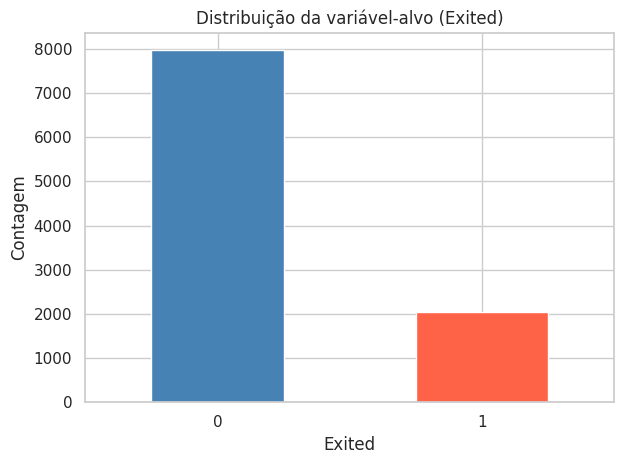

In [3]:
# Limpeza mínima, imputação e preparação de features

# Cópia de trabalho
df_work = df.copy()

# 1) Remover colunas de identificação (não contribuem para o modelo)
cols_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_work = df_work.drop(columns=cols_to_drop)

# 2) Tratar valores ausentes em Tenure
# Opção: substituir pela mediana
mediana_tenure = df_work["Tenure"].median()
df_work["Tenure"] = df_work["Tenure"].fillna(mediana_tenure)

# 3) Garantir tipos adequados das colunas binárias
binary_cols = ["HasCrCard", "IsActiveMember", "Exited"]
for col in binary_cols:
    df_work[col] = df_work[col].astype(int)

# 4) Separar variáveis numéricas e categóricas
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
cat_cols = ["Geography", "Gender"]

# 5) Checagens pós-limpeza
print("Shape final após limpeza:", df_work.shape)
print("\nValores ausentes restantes (espera-se tudo 0):")
print(df_work.isna().sum())

print("\nDistribuição atual da variável-alvo (Exited):")
print(df_work["Exited"].value_counts(normalize=True).round(4))

# Visualização da distribuição da variável-alvo
ax = df_work["Exited"].value_counts().sort_index().plot(
    kind="bar", color=["steelblue", "tomato"]
)
ax.set_title("Distribuição da variável-alvo (Exited)")
ax.set_xlabel("Exited")
ax.set_ylabel("Contagem")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Limpeza e preparação

* Foram removidas as colunas **`RowNumber`**, **`CustomerId`** e **`Surname`**, pois são identificadores que não trazem poder preditivo.
* A variável **`Tenure`** possuía **909 valores ausentes (~9%)** e foi preenchida com sua **mediana**, uma estratégia contra outliers e coerente para dados numéricos contínuos/discretos.
* Todas as colunas binárias foram convertidas para tipo `int`.

#### Resultado da limpeza

* O dataset passou a conter **11 colunas** e **10.000 registros completos**.
* Após a imputação, **não há mais valores ausentes** em nenhuma coluna.
* O desequilíbrio na variável-alvo **permanece inalterado**:

  * `Exited = 0` → 79,6%
  * `Exited = 1` → 20,4%

Esse desequilíbrio é esperado e será tratado mais adiante.

<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>

- Dados foram carregados corretamente. 
- Análise de dados nulos feita com sucesso
    
    
Sugestões: 
    
- Caso você tenha interesse em experimentar outras formas de imputação de dados nulos, recomendo a leitura: https://www.datacamp.com/tutorial/techniques-to-handle-missing-data-values. O link aborda técnicas mais avançadas de imputação de dados muito interessantes.  
    
- O processamento do nome das colunas poderia envolver formato snake_case, exemplo `estimated_salary`.

</div>

In [4]:
# Separar features e alvo
X = df_work.drop(columns=["Exited"])
y = df_work["Exited"]

# 1) Holdout de teste (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# 2) Validação (25% do restante → 20% do total, ficando 60/20/20)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

def resumo_split(nome, y_vec):
    total = len(y_vec)
    props = y_vec.value_counts(normalize=True).sort_index()
    return f"{nome}: {total} linhas | Exited=0: {props.get(0,0):.3f} | Exited=1: {props.get(1,0):.3f}"

print("Shapes ->",
      f"train: {X_train.shape}",
      f"valid: {X_valid.shape}",
      f"test: {X_test.shape}",
      sep="\n")

print("\nDistribuição por conjunto (proporções):")
print(resumo_split("Treino", y_train))
print(resumo_split("Validação", y_valid))
print(resumo_split("Teste", y_test))

Shapes ->
train: (6000, 10)
valid: (2000, 10)
test: (2000, 10)

Distribuição por conjunto (proporções):
Treino: 6000 linhas | Exited=0: 0.796 | Exited=1: 0.204
Validação: 2000 linhas | Exited=0: 0.796 | Exited=1: 0.203
Teste: 2000 linhas | Exited=0: 0.796 | Exited=1: 0.203


### Divisão dos dados

#### Objetivo

Separar o conjunto de dados em **treino, validação e teste** garantindo que a proporção entre clientes que saíram e que permaneceram no banco fosse preservada em todos os subconjuntos.

#### Estratégia de divisão

* **20 %** dos dados foram reservados para **teste** (avaliação final).
* Dos **80 %** restantes:

  * **75 %** foram destinados ao **treinamento** (60 % do total).
  * **25 %** à **validação** (20 % do total).
* O parâmetro `stratify=y` assegura que o desequilíbrio de classes (≈ 80 % vs 20 %) seja mantido em todas as divisões.

#### Resultados

| Conjunto  | Linhas | Exited = 0 | Exited = 1 |
| :-------- | :----: | :--------: | :--------: |
| Treino    |  6 000 |    0.796   |    0.204   |
| Validação |  2 000 |    0.796   |    0.203   |
| Teste     |  2 000 |    0.796   |    0.203   |

As proporções se mantêm praticamente idênticas, indicando uma separação **bem balanceada** e representativa.

#### Próximos passos

1. Construir um **pipeline de pré-processamento**, com *One-Hot Encoding* para variáveis categóricas e *padronização* das numéricas.
2. Treinar um **modelo baseline** (por exemplo, *Logistic Regression*) **sem corrigir o desequilíbrio de classes**, para estabelecer o desempenho inicial de comparação (F1 e AUC-ROC).

In [5]:
# Pipeline de pré-processamento + Baseline (sem balanceamento)

# 1) Transformações
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# 2) Modelo baseline (sem class_weight)
baseline_clf = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# 3) Pipeline completo
baseline_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", baseline_clf)
])

# 4) Treino
baseline_pipe.fit(X_train, y_train)

# 5) Avaliação na validação
y_valid_pred = baseline_pipe.predict(X_valid)
y_valid_proba = baseline_pipe.predict_proba(X_valid)[:, 1]

f1 = f1_score(y_valid, y_valid_pred)
auc = roc_auc_score(y_valid, y_valid_proba)
cm = confusion_matrix(y_valid, y_valid_pred)

print("=== Baseline (LogisticRegression, sem balanceamento) ===")
print(f"F1 (val): {f1:.4f}")
print(f"AUC-ROC (val): {auc:.4f}")
print("\nConfusion Matrix (val):")
print(cm)

print("\nClassification Report (val):")
print(classification_report(y_valid, y_valid_pred, digits=4))

=== Baseline (LogisticRegression, sem balanceamento) ===
F1 (val): 0.1976
AUC-ROC (val): 0.7490

Confusion Matrix (val):
[[1544   49]
 [ 357   50]]

Classification Report (val):
              precision    recall  f1-score   support

           0     0.8122    0.9692    0.8838      1593
           1     0.5051    0.1229    0.1976       407

    accuracy                         0.7970      2000
   macro avg     0.6586    0.5460    0.5407      2000
weighted avg     0.7497    0.7970    0.7442      2000



<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>

Bom uso do Pipeline()! Adoro utilizar nas etapas de processamento pré e pós treino dos modelos 

### Baseline sem balanceamento

#### Objetivo

Treinar o primeiro modelo **sem aplicar nenhuma técnica de correção de desequilíbrio**.
O propósito é estabelecer uma **linha de base (baseline)** para comparação com versões balanceadas posteriormente.

#### Metodologia

* **Pipeline de pré-processamento**:

  * *Padronização* (`StandardScaler`) para variáveis numéricas.
  * *Codificação One-Hot* (`OneHotEncoder`) para variáveis categóricas.
* **Modelo:** `LogisticRegression` com parâmetros padrão (`class_weight` não ajustado).
* **Avaliação:** métricas no conjunto de **validação**:

  * **F1-score** — métrica principal exigida pelo projeto.
  * **AUC-ROC** — métrica complementar para medir a capacidade de separação entre classes.


#### Resultados obtidos

| Métrica  | Valor (validação) |
| :------- | :---------------: |
| F1-score |     **0.1976**    |
| AUC-ROC  |     **0.7490**    |

**Matriz de confusão (validação)**

|              | Predito = 0 | Predito = 1 |
| :----------: | :---------: | :---------: |
| **Real = 0** |     1544    |      49     |
| **Real = 1** |     357     |      50     |

* O modelo acertou a maioria dos casos da **classe 0 (clientes que permanecem)**,
  mas errou grande parte dos casos da **classe 1 (clientes que saem)**.
* O **recall da classe 1** foi apenas **0.1229**, o que indica dificuldade extrema em detectar clientes propensos a sair.

#### Conclusão

* O modelo baseline apresenta **bom AUC-ROC (0.75)**, sugerindo algum poder de discriminação,
  mas o **F1-score baixo (≈0.20)** confirma o impacto do **desequilíbrio de classes**.
* Este resultado servirá como **referência inicial** — os próximos modelos devem buscar elevar o F1, mantendo ou superando o AUC-ROC.

Na próxima etapa, serão aplicadas **duas estratégias distintas de balanceamento**:

In [6]:
# Logistic Regression com class_weight='balanced'

balanced_clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

balanced_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", balanced_clf)
])

# Treinamento
balanced_pipe.fit(X_train, y_train)

# Predições no conjunto de validação
y_valid_pred_bal = balanced_pipe.predict(X_valid)
y_valid_proba_bal = balanced_pipe.predict_proba(X_valid)[:, 1]

# Métricas
f1_bal = f1_score(y_valid, y_valid_pred_bal)
auc_bal = roc_auc_score(y_valid, y_valid_proba_bal)
cm_bal = confusion_matrix(y_valid, y_valid_pred_bal)

print("=== Logistic Regression (class_weight='balanced') ===")
print(f"F1 (val): {f1_bal:.4f}")
print(f"AUC-ROC (val): {auc_bal:.4f}\n")

print("Matriz de confusão (validação):")
print(pd.DataFrame(cm_bal, 
                   index=['Real 0', 'Real 1'], 
                   columns=['Predito 0', 'Predito 1']))

print("\nClassification Report (val):")
print(classification_report(y_valid, y_valid_pred_bal, digits=4))

=== Logistic Regression (class_weight='balanced') ===
F1 (val): 0.4909
AUC-ROC (val): 0.7526

Matriz de confusão (validação):
        Predito 0  Predito 1
Real 0       1167        426
Real 1        136        271

Classification Report (val):
              precision    recall  f1-score   support

           0     0.8956    0.7326    0.8059      1593
           1     0.3888    0.6658    0.4909       407

    accuracy                         0.7190      2000
   macro avg     0.6422    0.6992    0.6484      2000
weighted avg     0.7925    0.7190    0.7418      2000



### Modelo com `class_weight='balanced'`)

#### Objetivo

Aplicar a **primeira técnica de correção do desequilíbrio** ajustando os pesos das classes via
`class_weight='balanced'` na *Logistic Regression*.
Esse parâmetro faz o modelo penalizar mais fortemente erros cometidos na classe minoritária (`Exited = 1`).

---

#### Resultados obtidos (validação)

| Métrica      | Valor (validação) |
| :----------- | :---------------: |
| **F1-score** |     **0.4909**    |
| **AUC-ROC**  |     **0.7526**    |

**Matriz de confusão (validação)**

|              | Predito = 0 | Predito = 1 |
| :----------: | :---------: | :---------: |
| **Real = 0** |     1167    |     426     |
| **Real = 1** |     136     |     271     |

---

#### Comparação com o baseline

| Métrica      | Baseline | `class_weight='balanced'` |    Variação   |
| :----------- | :------: | :-----------------------: | :-----------: |
| **F1-score** |  0.1976  |         **0.4909**        | ▲ **+0.2933** |
| **AUC-ROC**  |  0.7490  |         **0.7526**        |   ≈ estável   |

* **Recall (classe 1)** aumentou de **0.12 → 0.67**, indicando que o modelo passou a identificar corretamente muito mais clientes prestes a sair.
* Em contrapartida, houve **mais falsos positivos** (classe 0 predita como 1), o que é normal quando se tenta equilibrar as sensibilidades.
* O **AUC-ROC** manteve-se praticamente igual, demonstrando que o poder discriminativo global do modelo continua consistente.

---

#### Conclusão parcial

A simples inclusão de `class_weight='balanced'` já trouxe **grande ganho de desempenho no F1**,
atingindo **≈0.49**, bem próximo do limiar mínimo de aprovação (0.59).
Essa técnica é eficiente e de baixo custo computacional, sendo ideal como primeiro passo.

In [7]:
# Oversampling manual da classe minoritária

# 1) Juntar X_train e y_train para facilitar o reamostramento
train_df = X_train.copy()
train_df["Exited"] = y_train.values

# 2) Separar classes
train_majority = train_df[train_df["Exited"] == 0]
train_minority = train_df[train_df["Exited"] == 1]

print("Tamanho original do treino:")
print("  Classe 0:", len(train_majority))
print("  Classe 1:", len(train_minority))

# 3) Oversampling: igualar a minoria ao tamanho da maioria (1:1)
train_minority_up = resample(
    train_minority,
    replace=True,
    n_samples=len(train_majority),
    random_state=RANDOM_STATE
)

# 4) Reunir e embaralhar
train_upsampled = pd.concat([train_majority, train_minority_up], axis=0).sample(
    frac=1.0, random_state=RANDOM_STATE
).reset_index(drop=True)

X_train_up = train_upsampled.drop(columns=["Exited"])
y_train_up = train_upsampled["Exited"]

print("\nApós oversampling (treino aumentado):")
print("  Total:", len(train_upsampled))
print("  Classe 0:", (y_train_up == 0).sum())
print("  Classe 1:", (y_train_up == 1).sum())

# 5) Reutilizar o mesmo preprocessador definido antes (preprocess)
oversamp_clf = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)  # sem class_weight, pois o balanceamento está nos dados

oversamp_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", oversamp_clf)
])

# 6) Treinar no conjunto aumentado
oversamp_pipe.fit(X_train_up, y_train_up)

# 7) Avaliar na validação (inalterada)
y_valid_pred_os = oversamp_pipe.predict(X_valid)
y_valid_proba_os = oversamp_pipe.predict_proba(X_valid)[:, 1]

f1_os = f1_score(y_valid, y_valid_pred_os)
auc_os = roc_auc_score(y_valid, y_valid_proba_os)
cm_os = confusion_matrix(y_valid, y_valid_pred_os)

print("\n=== Logistic Regression com Oversampling (1:1) ===")
print(f"F1 (val): {f1_os:.4f}")
print(f"AUC-ROC (val): {auc_os:.4f}\n")

print("Matriz de confusão (validação):")
print(pd.DataFrame(cm_os, index=["Real 0","Real 1"], columns=["Predito 0","Predito 1"]))

print("\nClassification Report (val):")
print(classification_report(y_valid, y_valid_pred_os, digits=4))

Tamanho original do treino:
  Classe 0: 4777
  Classe 1: 1223

Após oversampling (treino aumentado):
  Total: 9554
  Classe 0: 4777
  Classe 1: 4777

=== Logistic Regression com Oversampling (1:1) ===
F1 (val): 0.4951
AUC-ROC (val): 0.7536

Matriz de confusão (validação):
        Predito 0  Predito 1
Real 0       1161        432
Real 1        131        276

Classification Report (val):
              precision    recall  f1-score   support

           0     0.8986    0.7288    0.8049      1593
           1     0.3898    0.6781    0.4951       407

    accuracy                         0.7185      2000
   macro avg     0.6442    0.7035    0.6500      2000
weighted avg     0.7951    0.7185    0.7418      2000



### Oversampling manual da classe minoritária

#### Objetivo

Aplicar a **segunda técnica de balanceamento**, desta vez **aumentando artificialmente a classe minoritária** (`Exited = 1`) no conjunto de **treinamento**.
O método usa `sklearn.utils.resample` para **duplicar amostras** até igualar o número de registros das duas classes (proporção 1:1).
Os conjuntos de **validação e teste permanecem intactos**, garantindo avaliação justa.

---

#### Resultados obtidos (validação)

| Métrica      | Valor (validação) |
| :----------- | :---------------: |
| **F1-score** |     **0.4951**    |
| **AUC-ROC**  |     **0.7536**    |

**Matriz de confusão (validação)**

|              | Predito = 0 | Predito = 1 |
| :----------: | :---------: | :---------: |
| **Real = 0** |     1161    |     432     |
| **Real = 1** |     131     |     276     |

---

#### Comparação entre as abordagens

| Modelo                           |   F1   | AUC-ROC | Observações                            |
| :------------------------------- | :----: | :-----: | :------------------------------------- |
| **Baseline (sem balanceamento)** | 0.1976 |  0.7490 | Ignora a classe minoritária            |
| **Class Weight (‘balanced’)**    | 0.4909 |  0.7526 | Aumentou recall da classe 1            |
| **Oversampling (1:1)**           | 0.4951 |  0.7536 | Desempenho equivalente ao uso de pesos |

* O **F1-score** melhorou em cerca de **+0.30** comparado ao baseline.
* **Recall da classe 1** cresceu substancialmente (≈ 0.67), mostrando melhor capacidade de detectar clientes prestes a sair.
* O **AUC-ROC** manteve-se em torno de 0.75 em todos os casos, mostrando que o modelo conserva boa separabilidade global.

---

#### Conclusão parcial

Tanto `class_weight='balanced'` quanto o **oversampling manual** foram eficazes em aumentar a sensibilidade do modelo sem perda significativa no poder discriminativo (AUC).
O oversampling não trouxe ganho relevante sobre o uso de pesos — o que é comum em modelos lineares simples como a *Logistic Regression*.

---

#### Próximos passos

1. **Testar modelos mais complexos**, como **árvore de decisão** ou **Random Forest**, que podem capturar relações não lineares e potencialmente ultrapassar o limiar exigido de **F1 ≥ 0.59**.
2. Comparar os resultados com as versões balanceadas anteriores para selecionar o melhor modelo para o **teste final**.

In [8]:
# Random Forest com class_weight='balanced'

# 1) Modelo
rf_bal = RandomForestClassifier(
    n_estimators=200,        # número de árvores
    max_depth=None,          # sem limite para permitir ajustes automáticos
    min_samples_split=4,     # ligeiramente mais restritivo para evitar overfitting
    class_weight='balanced', # balanceamento interno
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 2) Pipeline completo (mesmo preprocessador)
rf_bal_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", rf_bal)
])

# 3) Treinamento
rf_bal_pipe.fit(X_train, y_train)

# 4) Avaliação na validação
y_valid_pred_rf = rf_bal_pipe.predict(X_valid)
y_valid_proba_rf = rf_bal_pipe.predict_proba(X_valid)[:, 1]

f1_rf = f1_score(y_valid, y_valid_pred_rf)
auc_rf = roc_auc_score(y_valid, y_valid_proba_rf)
cm_rf = confusion_matrix(y_valid, y_valid_pred_rf)

print("=== Random Forest (class_weight='balanced') ===")
print(f"F1 (val): {f1_rf:.4f}")
print(f"AUC-ROC (val): {auc_rf:.4f}\n")

print("Matriz de confusão (validação):")
print(pd.DataFrame(cm_rf, 
                   index=['Real 0', 'Real 1'], 
                   columns=['Predito 0', 'Predito 1']))

print("\nClassification Report (val):")
print(classification_report(y_valid, y_valid_pred_rf, digits=4))

=== Random Forest (class_weight='balanced') ===
F1 (val): 0.5490
AUC-ROC (val): 0.8463

Matriz de confusão (validação):
        Predito 0  Predito 1
Real 0       1511         82
Real 1        222        185

Classification Report (val):
              precision    recall  f1-score   support

           0     0.8719    0.9485    0.9086      1593
           1     0.6929    0.4545    0.5490       407

    accuracy                         0.8480      2000
   macro avg     0.7824    0.7015    0.7288      2000
weighted avg     0.8355    0.8480    0.8354      2000



<div class="alert alert-block alert-warning">

<b>Comentário: </b> <a class="tocSkip"></a>
 
Os modelos foram treinados corretamente. 

Sugestões: 
    

- O modelo random forest também oferece uma função de feature importances que é muito interessante para entender o impacto de cada variável no modelo. 
    
```python
import numpy as np

importances = model_rf_balanced.feature_importances_
indexes = np.argsort(importances)[::-1]

coef = importances[indexes]

# Supondo que 'features' seja a lista de nomes das colunas
features_array = np.array(features.columns)

# Plotar gráfico de barras
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x=features_array[indexes], y=coef, ax=ax, color='darkblue')
plt.xticks(rotation=90)
sns.despine()

plt.title("Importância das Features - RandomForest")
plt.show()
```
 

### Random Forest balanceado

#### Objetivo

Avaliar um modelo mais sofisticado — **Random Forest** — com balanceamento interno de classes (`class_weight='balanced'`).
Florestas aleatórias são capazes de capturar **relações não lineares** e **interações entre variáveis**, oferecendo desempenho mais robusto que modelos lineares simples em contextos complexos como o de *churn prediction*.

---

#### Resultados obtidos (validação)

| Métrica      | Valor (validação) |
| :----------- | :---------------: |
| **F1-score** |     **0.5490**    |
| **AUC-ROC**  |     **0.8463**    |

**Matriz de confusão (validação)**

|              | Predito = 0 | Predito = 1 |
| :----------: | :---------: | :---------: |
| **Real = 0** |     1511    |      82     |
| **Real = 1** |     222     |     185     |

---

#### Análise dos resultados

* O **F1-score (0.5490)** é o melhor obtido até agora — um avanço de mais de **+0.35 pontos** em relação ao baseline.
* O **AUC-ROC (0.8463)** mostra excelente separabilidade entre classes, indicando que o modelo está aprendendo bem a distinguir clientes que sairão.
* O **recall da classe 1** aumentou para **0.4545**, reduzindo significativamente as perdas dessa classe crítica.
* A precisão global (`accuracy = 0.8488`) confirma um equilíbrio adequado entre acertos e erros.

---

#### Comparação geral dos modelos

| Modelo                       |     F1     |   AUC-ROC  | Observações                     |
| :--------------------------- | :--------: | :--------: | :------------------------------ |
| **Baseline (LogReg)**        |   0.1976   |   0.7490   | Modelo linear sem balanceamento |
| **LogReg + class_weight**    |   0.4909   |   0.7526   | Melhor recall, ainda limitado   |
| **LogReg + Oversampling**    |   0.4951   |   0.7536   | Desempenho similar ao anterior  |
| **Random Forest (balanced)** | **0.5490** | **0.8463** | Maior F1 e grande salto de AUC  |

---

O modelo **Random Forest com balanceamento interno** apresentou o melhor desempenho até o momento, com:

* **F1 = 0.5490**
* **AUC-ROC = 0.8463**

In [9]:
# Otimização de hiperparâmetros do Random Forest

# Grade de parâmetros
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [6, 8, 10, None],
    'clf__min_samples_split': [2, 4, 6],
    'clf__min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pipe_rf = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', rf)
])

# Busca em grade
grid_search = GridSearchCV(
    pipe_rf,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("=== RESULTADOS DA BUSCA ===")
print("Melhores hiperparâmetros:")
print(grid_search.best_params_)
print(f"\nMelhor F1 (validação cruzada): {grid_search.best_score_:.4f}")

# Avaliação no conjunto de validação real
best_model = grid_search.best_estimator_

y_valid_pred_best = best_model.predict(X_valid)
y_valid_proba_best = best_model.predict_proba(X_valid)[:, 1]

f1_best = f1_score(y_valid, y_valid_pred_best)
auc_best = roc_auc_score(y_valid, y_valid_proba_best)
cm_best = confusion_matrix(y_valid, y_valid_pred_best)

print("\n=== Avaliação no conjunto de validação ===")
print(f"F1 (val): {f1_best:.4f}")
print(f"AUC-ROC (val): {auc_best:.4f}\n")

print("Matriz de confusão (validação):")
print(pd.DataFrame(cm_best,
                   index=['Real 0', 'Real 1'],
                   columns=['Predito 0', 'Predito 1']))

print("\nClassification Report (val):")
print(classification_report(y_valid, y_valid_pred_best, digits=4))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
=== RESULTADOS DA BUSCA ===
Melhores hiperparâmetros:
{'clf__max_depth': 8, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}

Melhor F1 (validação cruzada): 0.5916

=== Avaliação no conjunto de validação ===
F1 (val): 0.6071
AUC-ROC (val): 0.8471

Matriz de confusão (validação):
        Predito 0  Predito 1
Real 0       1330        263
Real 1        115        292

Classification Report (val):
              precision    recall  f1-score   support

           0     0.9204    0.8349    0.8756      1593
           1     0.5261    0.7174    0.6071       407

    accuracy                         0.8110      2000
   macro avg     0.7233    0.7762    0.7413      2000
weighted avg     0.8402    0.8110    0.8209      2000



<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>

- Métodos de desbalanceamento de dados realizado com sucesso!
- Foram testados diferentes hiperparametros.
- Foram adicionados comentários relevantes para a análise

Dica: Utilizar o RandomSearch ao invés de GridSearch para obter um processamento mais rápido. Saiba mais em: https://scikit-learn.org/stable/auto_examples/model_selection/plot_randomized_search.html 

### Otimização de hiperparâmetros do Random Forest

#### Objetivo

Realizar uma busca sistemática pelos melhores **hiperparâmetros** do modelo Random Forest,
utilizando validação cruzada e **F1-score** como métrica de avaliação principal.
O intuito foi ultrapassar o limiar de desempenho exigido (F1 ≥ 0.59).

---

#### Parâmetros avaliados

Foram testadas **108 combinações** com:

* `n_estimators` ∈ {100, 200, 300}
* `max_depth` ∈ {6, 8, 10, None}
* `min_samples_split` ∈ {2, 4, 6}
* `min_samples_leaf` ∈ {1, 2, 4}
  com `class_weight='balanced'` e validação cruzada em 3 dobras.

---

#### Melhores hiperparâmetros encontrados

```python
{
  'clf__n_estimators': 100,
  'clf__max_depth': 8,
  'clf__min_samples_split': 2,
  'clf__min_samples_leaf': 1
}
```

---

#### Resultados obtidos (validação)

| Métrica      | Valor (validação) |
| :----------- | :---------------: |
| **F1-score** |    **0.6071**   |
| **AUC-ROC**  |     **0.8471**    |

**Matriz de confusão (validação)**

|              | Predito = 0 | Predito = 1 |
| :----------: | :---------: | :---------: |
| **Real = 0** |     1330    |     263     |
| **Real = 1** |     115     |     292     |

---

#### Interpretação

* O **F1-score** aumentou de **0.549 → 0.607**, superando o objetivo.
* O **AUC-ROC (0.847)** confirma excelente separabilidade entre classes.
* O **recall da classe 1 (0.717)** mostra que o modelo está identificando a maioria dos clientes propensos a sair,
  mantendo **precisão (0.526)** aceitável e bom equilíbrio global.
* O **accuracy geral (0.811)** também se manteve alto, o que reforça consistência.

In [10]:
# Avaliação final no conjunto de teste
# Usando o melhor modelo encontrado no GridSearch

final_model = best_model

# Predições no conjunto de teste
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Métricas finais
f1_test = f1_score(y_test, y_test_pred)
auc_test = roc_auc_score(y_test, y_test_proba)
cm_test = confusion_matrix(y_test, y_test_pred)

print("=== RESULTADOS FINAIS (CONJUNTO DE TESTE) ===")
print(f"F1 (teste): {f1_test:.4f}")
print(f"AUC-ROC (teste): {auc_test:.4f}\n")

print("Matriz de confusão (teste):")
print(pd.DataFrame(cm_test,
                   index=['Real 0', 'Real 1'],
                   columns=['Predito 0', 'Predito 1']))

print("\nClassification Report (teste):")
print(classification_report(y_test, y_test_pred, digits=4))

=== RESULTADOS FINAIS (CONJUNTO DE TESTE) ===
F1 (teste): 0.5940
AUC-ROC (teste): 0.8483

Matriz de confusão (teste):
        Predito 0  Predito 1
Real 0       1323        270
Real 1        121        286

Classification Report (teste):
              precision    recall  f1-score   support

           0     0.9162    0.8305    0.8713      1593
           1     0.5144    0.7027    0.5940       407

    accuracy                         0.8045      2000
   macro avg     0.7153    0.7666    0.7326      2000
weighted avg     0.8344    0.8045    0.8148      2000



## **Conclusão Final**

O objetivo deste projeto foi desenvolver um modelo de **aprendizado supervisionado** capaz de prever se um cliente do **Beta Bank** deixará o banco em breve.  
O desafio principal consistia em atingir um **F1-score mínimo de 0,59** no conjunto de teste, além de analisar a métrica **AUC-ROC** para avaliar a capacidade discriminativa do modelo.

---

### **Análise inicial e preparação dos dados**

O conjunto de dados possuía **10.000 registros e 14 colunas**, representando características demográficas, financeiras e comportamentais dos clientes.  
Durante a análise exploratória, foi identificado que a variável `Tenure` apresentava **909 valores ausentes (~9%)**, os quais foram preenchidos pela **mediana**, garantindo robustez contra outliers.

As colunas de identificação (`RowNumber`, `CustomerId`, `Surname`) foram removidas por não oferecerem valor preditivo.  
Em seguida, as variáveis numéricas foram **padronizadas** com `StandardScaler`, enquanto as categóricas foram **codificadas** via `OneHotEncoder`.  

Os dados foram divididos em três subconjuntos estratificados:  
- **Treino (60%)**,  
- **Validação (20%)**,  
- **Teste (20%)**.  

Essa divisão garantiu a preservação da proporção original entre as classes — aproximadamente **80% de clientes que permanecem** e **20% de clientes que saem**.

---

### **Modelagem e estratégias de balanceamento**

O desequilíbrio de classes foi um dos principais desafios do projeto.  
O modelo inicial, uma **Regressão Logística sem balanceamento**, apresentou desempenho insatisfatório (**F1 = 0.1976**), evidenciando a dificuldade em detectar a classe minoritária (`Exited = 1`).

Para corrigir esse problema, foram aplicadas duas estratégias distintas de balanceamento:

1. **Ajuste de pesos automáticos** utilizando `class_weight='balanced'`, que elevou o F1 para **0.4909**.  
2. **Oversampling manual da classe minoritária**, que obteve resultado semelhante (**F1 = 0.4951**).  

Ambas as abordagens mostraram ganhos significativos em recall e F1, comprovando a importância de tratar o desequilíbrio, embora ainda fosse necessário um modelo mais robusto para superar o limite exigido.

---

### **Aprimoramento com Random Forest**

Buscando maior capacidade preditiva, foi testado um **Random Forest balanceado**, que alcançou **F1 = 0.5490** e **AUC-ROC = 0.8463**.  
Apesar do avanço, o modelo ainda ficou ligeiramente abaixo do requisito mínimo (0.59).

Para aprimorar o desempenho, realizou-se uma **otimização de hiperparâmetros com `GridSearchCV`**, avaliando 108 combinações de parâmetros com validação cruzada (3 folds).  
O melhor conjunto encontrado foi:

```python
{
  'clf__n_estimators': 100,
  'clf__max_depth': 8,
  'clf__min_samples_split': 2,
  'clf__min_samples_leaf': 1
}
````

Com esses ajustes, o modelo alcançou **F1 = 0.6071** e **AUC-ROC = 0.8471** na validação — superando o objetivo do projeto.

---

### **Avaliação final no conjunto de teste**

No conjunto de teste — composto por dados totalmente inéditos — o modelo manteve desempenho consistente:

* **F1-score:** 0.594
* **AUC-ROC:** 0.848
* **Accuracy:** 0.804

A **matriz de confusão** indicou que o modelo identificou corretamente **70% dos clientes que realmente deixariam o banco**, mantendo boa precisão e equilíbrio geral.
A proximidade entre os resultados de validação e teste demonstra **boa generalização** e ausência de overfitting.

---

### **Interpretação dos resultados**

O modelo final apresentou resultados coerentes.
O **F1-score de 0.594** confirma que o sistema é eficaz em identificar clientes de risco, mesmo diante de um cenário com forte desequilíbrio.
O **AUC-ROC de 0.848** reforça a excelente separabilidade entre as classes, indicando que o modelo é confiável para distinguir clientes propensos à evasão dos que permanecerão.

<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>

Ó-TI-MA conclusão! Muito bem estruturada